In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
import optuna
pd.set_option('display.max_columns', None)

c:\Users\abhir\anaconda3\envs\wildfire-prediction\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
training_df=pd.read_csv("../Datasets/training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.4600,95.42882,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,1012.03436,3.9,4.0,0.0,1.0,0.0,0.057978,7.421590,12.229406,112.833694,137.38599,11.879999,10.7600,13.110001,14.0100,21.910000,0.275,0.318,0.195,0.026,1
1,10.4535,95.42859,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,1011.91230,3.9,4.0,0.0,1.0,0.0,0.057956,7.421590,12.229406,112.833694,137.38599,11.879999,10.7535,13.103500,14.0035,21.903500,0.275,0.318,0.195,0.026,1
2,10.4145,95.42721,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,1011.18120,3.9,4.0,0.0,1.0,0.0,0.057823,7.421590,12.229406,112.833694,137.38599,11.879999,10.7145,13.064501,13.9645,21.864500,0.275,0.318,0.195,0.026,1
3,9.2235,99.66392,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,1010.78680,2.7,3.0,0.0,0.0,0.0,0.003924,5.937272,11.885453,75.963730,125.13428,13.320000,10.4235,12.823500,13.7235,21.923500,0.273,0.324,0.201,0.020,1
4,9.2430,99.66399,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,1011.15370,2.7,3.0,0.0,0.0,0.0,0.003929,5.937272,11.885453,75.963730,125.13428,13.320000,10.4430,12.842999,13.7430,21.942999,0.273,0.324,0.201,0.020,1


In [3]:
training_df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'rain', 'snowfall',
       'snow_depth', 'weather_code', 'pressure_msl', 'surface_pressure',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'et0_fao_evapotranspiration', 'vapour_pressure_deficit',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
       'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm',
       'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm',
       'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm',
       'soil_moisture_100_to_255cm', 'fire'],
      dtype='object')

In [4]:
training_df.shape

(113896, 31)

In [5]:
X=training_df.drop('fire',axis=1)
y=training_df['fire']

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
X_train

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
86276,23.581500,30.182863,5.0815,20.782309,0.0,0.0,0.0,0.0,0.0,1013.1,970.46250,0.600000,0.0,0.0,2.0,0.129170,2.032494,10.948973,15.294704,207.407490,206.564990,29.519999,33.081500,28.081500,21.581500,18.381498,0.076,0.094,0.072,0.155
19582,16.959000,21.806984,-5.0410,11.936909,0.0,0.0,0.0,0.0,0.0,1011.3,919.23160,0.000000,0.0,0.0,0.0,0.138545,1.512834,15.328561,27.908709,260.537750,263.333440,24.119999,19.809000,25.459000,21.009000,16.809000,0.005,0.088,0.150,0.186
76324,14.174001,43.637997,1.9740,11.599044,0.0,0.0,0.0,0.0,0.0,1012.2,815.89230,0.000000,0.0,0.0,0.0,0.043197,0.912416,5.315336,13.183080,298.300660,304.992100,36.000000,18.273998,17.973999,17.973999,13.523999,0.136,0.151,0.166,0.264
87200,39.696500,27.070065,17.2465,39.359700,0.0,0.0,0.0,0.0,0.0,1002.9,1002.13367,19.800000,0.0,3.0,60.0,0.360456,5.288937,19.855560,25.969950,135.000100,136.123210,34.200000,48.746500,42.246500,39.046500,29.846500,0.018,0.125,0.034,0.081
18455,3.293500,75.322950,-0.6565,-0.988489,0.0,0.0,0.0,0.0,0.0,1022.1,885.48755,0.000000,0.0,0.0,0.0,0.014473,0.191470,14.113653,24.482647,275.855930,269.157500,45.000000,6.193500,11.593500,12.393500,14.793500,0.030,0.152,0.207,0.206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76820,15.552000,10.473747,-15.4480,6.746056,0.0,0.0,0.0,0.0,0.0,1023.3,994.37244,0.000000,0.0,0.0,0.0,0.280982,1.583402,35.647274,57.735970,33.048134,32.005356,72.000000,15.852001,17.752000,19.452000,21.802000,0.100,0.137,0.102,0.161
110268,20.286001,55.862114,11.1860,20.166687,0.0,0.0,0.0,0.0,0.0,1017.3,982.83680,0.000000,0.0,0.0,0.0,0.008225,1.050968,3.319036,6.792466,12.528798,57.994660,9.720000,22.186000,25.886002,25.786001,22.986000,0.093,0.151,0.190,0.269
103694,22.719000,36.850560,7.2190,20.714050,0.0,0.0,0.0,0.0,0.0,1013.7,1003.23060,0.000000,0.0,0.0,0.0,0.081602,1.745017,8.825508,13.551500,348.231720,343.009100,12.599999,25.619001,30.569000,29.319000,26.819000,0.129,0.147,0.150,0.172
860,10.053500,99.333230,9.9535,9.476762,0.0,0.0,0.0,0.0,3.0,1018.7,1018.20870,90.000000,100.0,0.0,0.0,0.000000,0.008230,3.976330,8.121970,84.805664,102.804260,9.000000,9.403500,14.153500,15.403500,19.503500,0.148,0.163,0.180,0.026


In [8]:
y_train

86276     0
19582     1
76324     0
87200     0
18455     1
         ..
76820     0
110268    0
103694    0
860       1
15795     1
Name: fire, Length: 91116, dtype: int64

In [9]:
X_test

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm
57526,24.078500,54.823914,14.4285,25.315160,0.0,0.0,0.0,0.0,0.0,1012.5,907.14760,0.000000,0.0,0.0,0.0,0.112685,1.354402,1.484318,1.609969,194.036270,243.435010,15.119999,25.978500,21.828500,21.578500,20.478500,0.132,0.160,0.218,0.323
32133,16.934500,48.455890,5.9845,15.446991,0.0,0.0,0.0,0.0,0.0,1014.9,1015.25867,0.900000,1.0,0.0,0.0,0.298856,0.995594,3.319036,3.545589,102.528800,113.962494,15.480000,17.684500,14.434501,22.834500,27.684500,0.190,0.014,0.003,0.091
70733,20.943499,28.005545,1.7435,18.766342,0.0,0.0,0.0,0.0,1.0,1016.5,900.42145,28.500002,0.0,0.0,95.0,0.012253,1.785594,2.305125,4.843305,38.659830,131.987140,10.080000,21.643500,24.143500,22.293499,20.143500,0.131,0.153,0.215,0.322
59482,27.838999,14.744609,-1.4110,24.194191,0.0,0.0,0.0,0.0,1.0,1015.6,846.84644,21.000000,0.0,0.0,70.0,0.641553,3.193788,16.645864,23.006226,201.571370,200.136380,57.600000,29.639000,24.239000,24.338999,21.139000,0.076,0.125,0.144,0.189
18387,27.536999,11.872372,-4.5630,26.002825,0.0,0.0,0.0,0.0,0.0,1013.1,1015.17420,18.900002,0.0,0.0,63.0,0.553462,3.243856,3.600000,4.104631,36.869990,52.124958,17.640000,31.786999,21.187000,20.437000,23.487000,0.040,0.114,0.132,0.088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91883,20.382500,36.180637,4.8825,18.655153,0.0,0.0,0.0,0.0,0.0,1010.6,891.43610,0.000000,0.0,0.0,0.0,0.018892,1.529041,3.319036,1.297998,310.601230,303.690100,6.120000,15.082500,26.132500,27.382500,26.632500,0.023,0.019,0.103,0.171
50234,34.371998,28.604473,13.5720,36.124600,0.0,0.0,0.0,0.0,0.0,1013.2,887.74260,0.000000,0.0,0.0,0.0,0.841965,3.875689,12.964998,17.227419,271.591100,280.840270,46.440000,33.072000,25.972000,20.321999,13.722000,0.134,0.180,0.253,0.336
80560,22.031500,67.043400,15.6315,23.357990,0.0,0.0,0.0,0.0,0.0,1012.6,969.76575,0.600000,0.0,1.0,0.0,0.006319,0.873084,4.024922,3.096837,10.304792,35.537766,6.840000,25.431500,32.281500,29.681500,25.981499,0.074,0.118,0.075,0.155
75854,18.895000,12.850369,-10.3050,15.776978,0.0,0.0,0.0,0.0,0.0,1017.7,969.01733,0.900000,1.0,0.0,0.0,0.427531,1.904168,5.771239,7.289444,273.576260,290.224950,20.880001,20.995000,11.795000,12.495001,15.145000,0.065,0.189,0.107,0.281


In [10]:
y_test

57526     0
32133     1
70733     0
59482     0
18387     1
         ..
91883     0
50234     1
80560     0
75854     0
100898    0
Name: fire, Length: 22780, dtype: int64

In [11]:
scaler = StandardScaler()

X_train_transformed = scaler.fit_transform(X_train)
X_test_transformed = scaler.transform(X_test)

In [12]:
from sklearn.svm import LinearSVC


Training LinearSVC with C=0.01
Training Accuracy: 0.6537
Testing Accuracy: 0.6568
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.60      0.63     11258
           1       0.64      0.72      0.68     11522

    accuracy                           0.66     22780
   macro avg       0.66      0.66      0.66     22780
weighted avg       0.66      0.66      0.66     22780



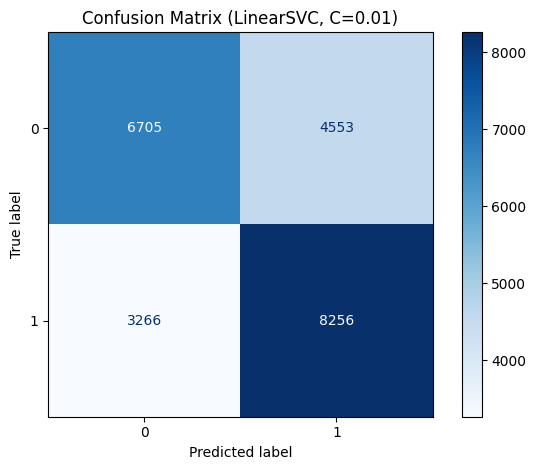

ROC AUC Score: 0.6978


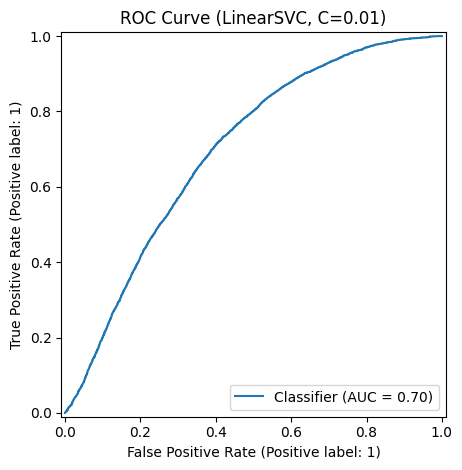


Training LinearSVC with C=0.1
Training Accuracy: 0.6559
Testing Accuracy: 0.6580
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.60      0.63     11258
           1       0.65      0.72      0.68     11522

    accuracy                           0.66     22780
   macro avg       0.66      0.66      0.66     22780
weighted avg       0.66      0.66      0.66     22780



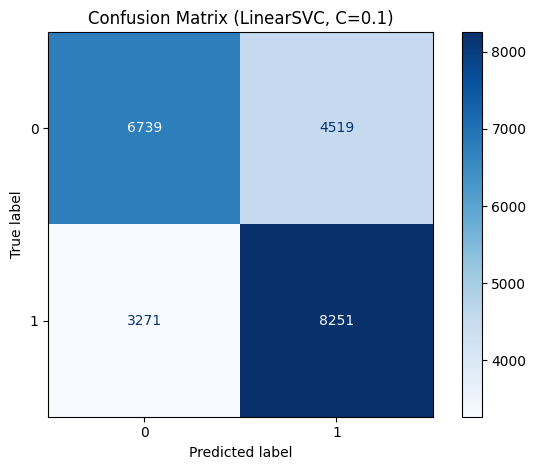

ROC AUC Score: 0.6998


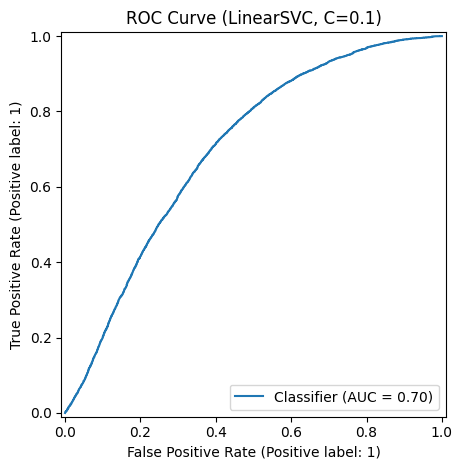


Training LinearSVC with C=1
Training Accuracy: 0.6559
Testing Accuracy: 0.6582
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.60      0.63     11258
           1       0.65      0.72      0.68     11522

    accuracy                           0.66     22780
   macro avg       0.66      0.66      0.66     22780
weighted avg       0.66      0.66      0.66     22780



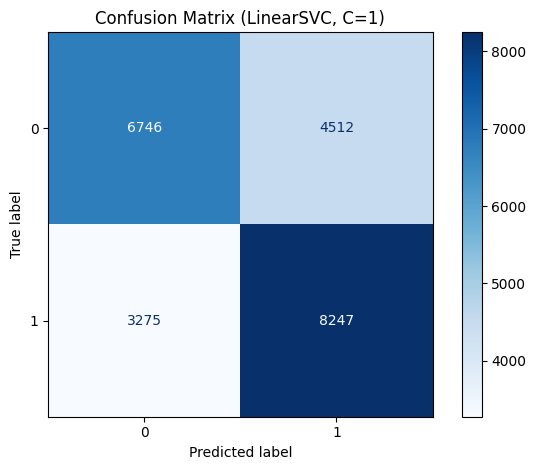

ROC AUC Score: 0.7000


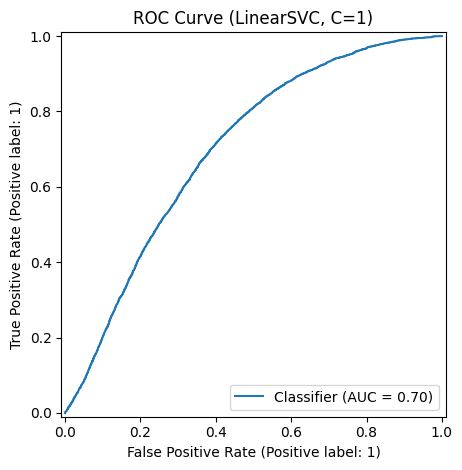


Training LinearSVC with C=10
Training Accuracy: 0.6558
Testing Accuracy: 0.6580
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.60      0.63     11258
           1       0.65      0.72      0.68     11522

    accuracy                           0.66     22780
   macro avg       0.66      0.66      0.66     22780
weighted avg       0.66      0.66      0.66     22780



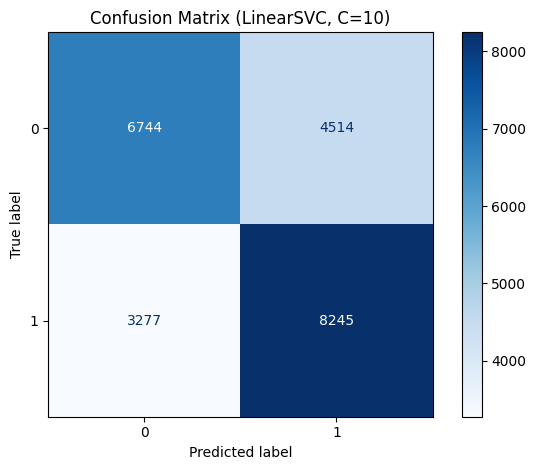

ROC AUC Score: 0.7000


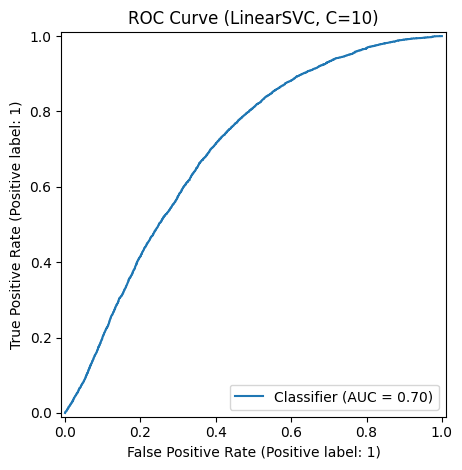


Training LinearSVC with C=100
Training Accuracy: 0.6558
Testing Accuracy: 0.6581
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.60      0.63     11258
           1       0.65      0.72      0.68     11522

    accuracy                           0.66     22780
   macro avg       0.66      0.66      0.66     22780
weighted avg       0.66      0.66      0.66     22780



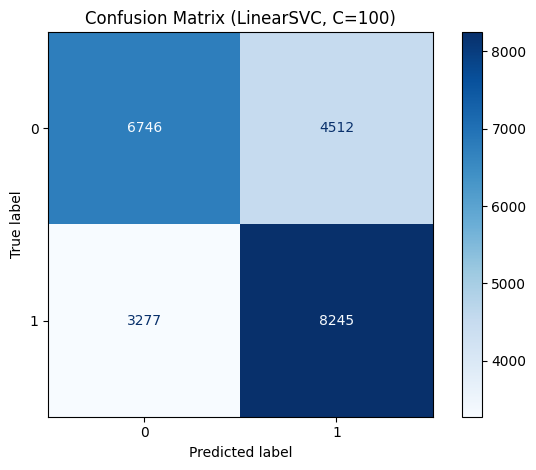

ROC AUC Score: 0.7000


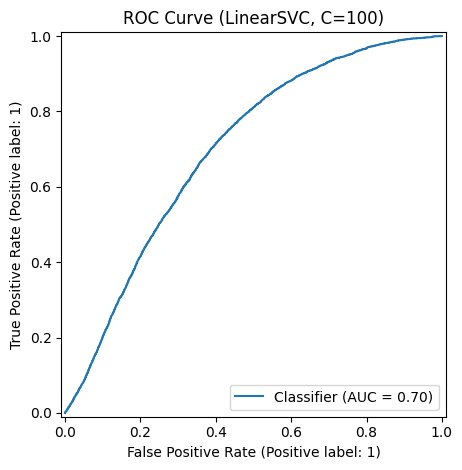

In [13]:
# Try different C values for linear kernel
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:
    print(f"\nTraining LinearSVC with C={C}")
    model = LinearSVC(C=C, max_iter=10000, random_state=42)
    model.fit(X_train_transformed, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)

    # Accuracy
    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

    # Classification Report
    print("Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Blues')
    plt.title(f"Confusion Matrix (LinearSVC, C={C})")
    plt.tight_layout()
    plt.show()

    # ROC AUC (binary only)
    y_scores = model.decision_function(X_test_transformed)
    auc = roc_auc_score(y_test, y_scores)
    print(f"ROC AUC Score: {auc:.4f}")

    RocCurveDisplay.from_predictions(y_test, y_scores)
    plt.title(f"ROC Curve (LinearSVC, C={C})")
    plt.tight_layout()
    plt.show()


No difference between C = 1 and C = 100

In [14]:
# Combine and sample
df_poly = pd.concat([X, y], axis=1).sample(n=10000, random_state=42)
X_poly = df_poly.drop(columns=y.name)
y_poly = df_poly[y.name]

# Split and scale
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_poly_transformed = scaler.fit_transform(X_train_poly)
X_test_poly_transformed = scaler.transform(X_test_poly)



Training SVC with kernel='poly', C=0.01, degree=3
Training Accuracy: 0.5219
Testing Accuracy: 0.5235
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.69      0.05      0.09       979
           1       0.52      0.98      0.68      1021

    accuracy                           0.52      2000
   macro avg       0.60      0.51      0.38      2000
weighted avg       0.60      0.52      0.39      2000



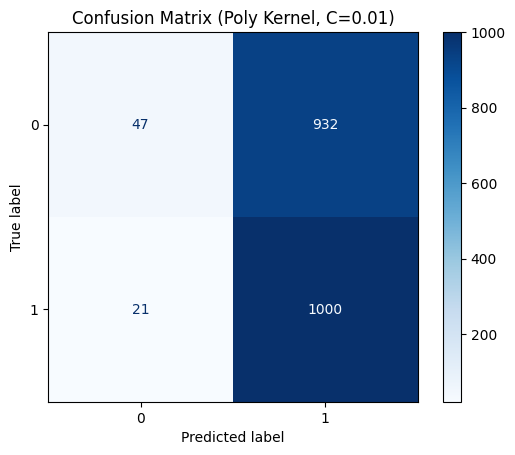

ROC AUC Score: 0.6222


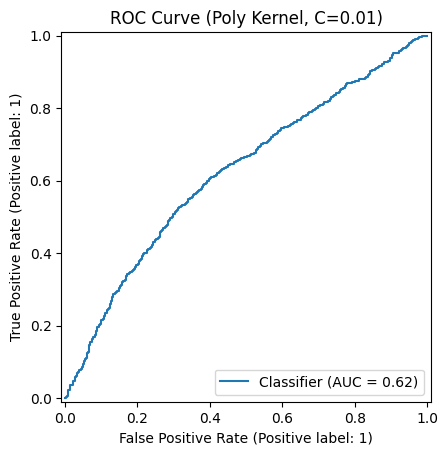


Training SVC with kernel='poly', C=0.1, degree=3
Training Accuracy: 0.6408
Testing Accuracy: 0.6220
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.66      0.47      0.55       979
           1       0.60      0.77      0.68      1021

    accuracy                           0.62      2000
   macro avg       0.63      0.62      0.61      2000
weighted avg       0.63      0.62      0.61      2000



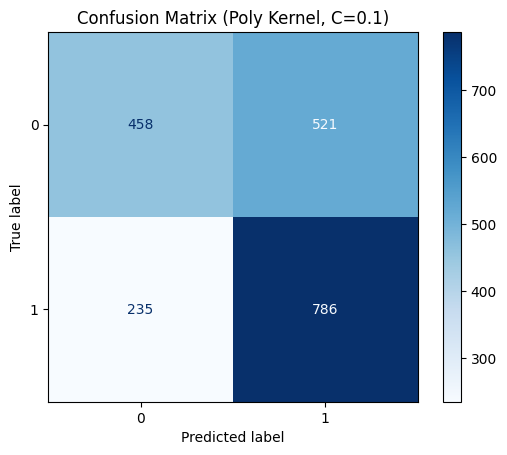

ROC AUC Score: 0.6691


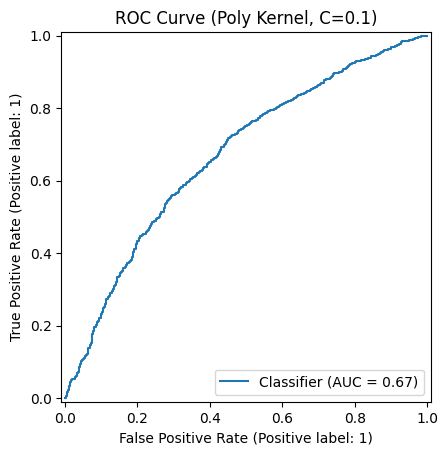


Training SVC with kernel='poly', C=1, degree=3
Training Accuracy: 0.7011
Testing Accuracy: 0.6630
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.66      0.63      0.65       979
           1       0.66      0.69      0.68      1021

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000



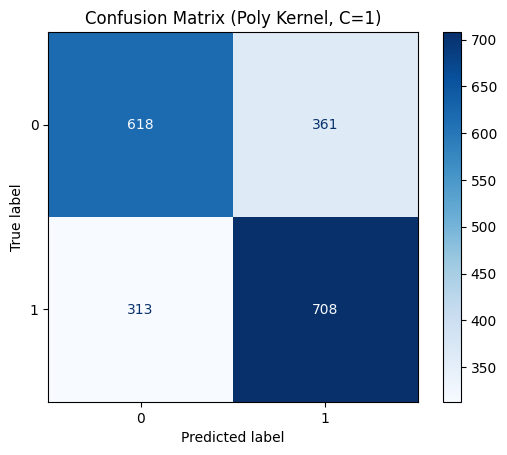

ROC AUC Score: 0.7185


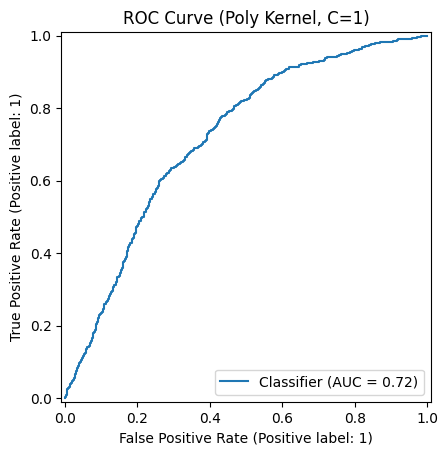


Training SVC with kernel='poly', C=10, degree=3
Training Accuracy: 0.7699
Testing Accuracy: 0.7110
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.74      0.64      0.68       979
           1       0.69      0.78      0.73      1021

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000



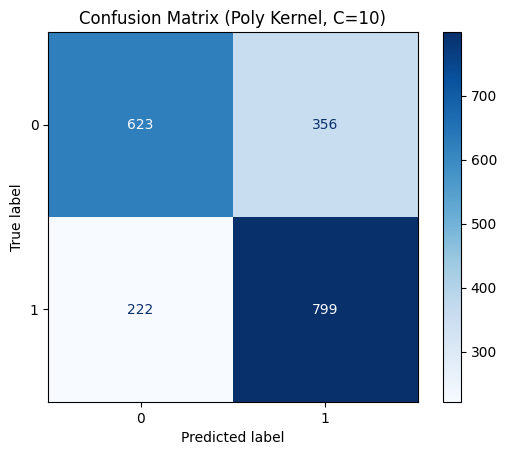

ROC AUC Score: 0.7604


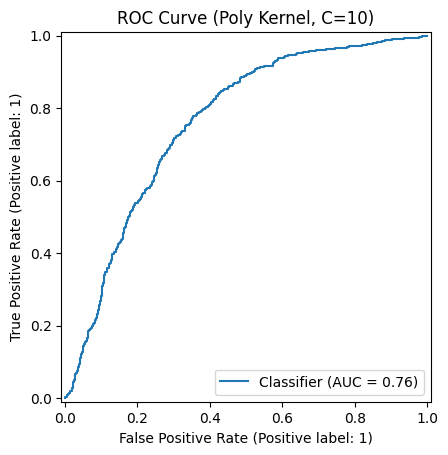


Training SVC with kernel='poly', C=100, degree=3
Training Accuracy: 0.8243
Testing Accuracy: 0.7270
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.76      0.64      0.70       979
           1       0.70      0.81      0.75      1021

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.72      2000
weighted avg       0.73      0.73      0.72      2000



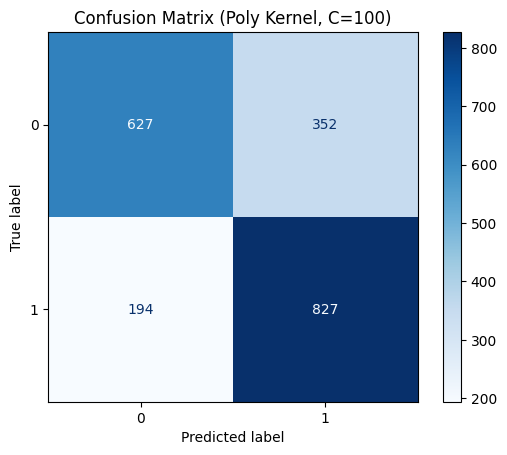

ROC AUC Score: 0.7700


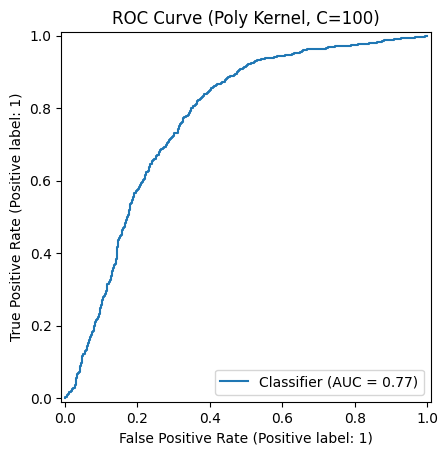

In [15]:
# C values to test
C_values = [0.01, 0.1, 1, 10, 100]

# Fast poly kernel on subset
for C in C_values:
    print(f"\nTraining SVC with kernel='poly', C={C}, degree=3")

    model = SVC(kernel='poly', C=C, degree=3, random_state=42)
    model.fit(X_train_poly_transformed, y_train_poly)

    # Predictions
    y_train_pred = model.predict(X_train_poly_transformed)
    y_test_pred = model.predict(X_test_poly_transformed)

    # Accuracy
    print(f"Training Accuracy: {accuracy_score(y_train_poly, y_train_pred):.4f}")
    print(f"Testing Accuracy: {accuracy_score(y_test_poly, y_test_pred):.4f}")

    # Classification Report
    print("Classification Report (Test Set):")
    print(classification_report(y_test_poly, y_test_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test_poly, y_test_pred)
    ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Blues')
    plt.title(f"Confusion Matrix (Poly Kernel, C={C})")
    plt.show()

    # ROC AUC
    if len(np.unique(y_test_poly)) == 2:
        y_scores = model.decision_function(X_test_poly_transformed)
        auc = roc_auc_score(y_test_poly, y_scores)
        print(f"ROC AUC Score: {auc:.4f}")

        RocCurveDisplay.from_predictions(y_test_poly, y_scores)
        plt.title(f"ROC Curve (Poly Kernel, C={C})")
        plt.show()



Training SVC with kernel='rbf', C=0.01
Training Accuracy: 0.6451
Testing Accuracy: 0.6474
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.59      0.62     11258
           1       0.64      0.71      0.67     11522

    accuracy                           0.65     22780
   macro avg       0.65      0.65      0.65     22780
weighted avg       0.65      0.65      0.65     22780



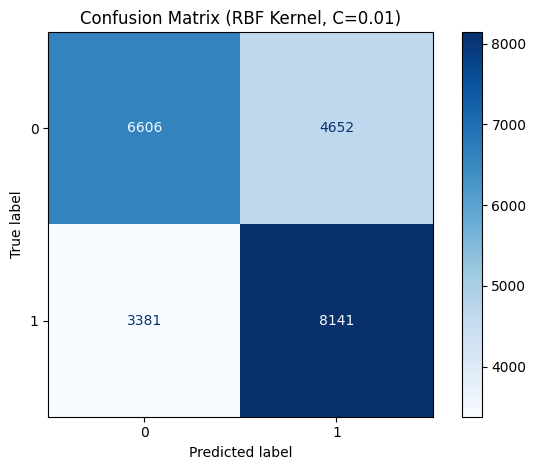

ROC AUC Score: 0.6989


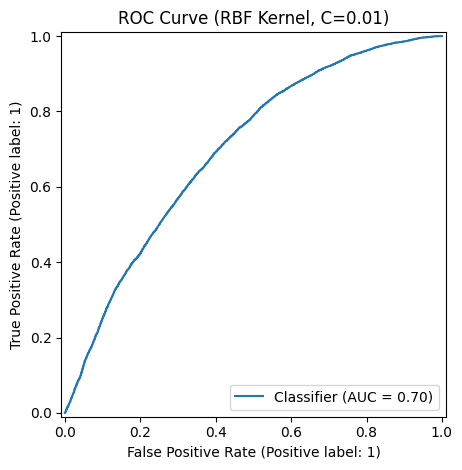


Training SVC with kernel='rbf', C=0.1
Training Accuracy: 0.7128
Testing Accuracy: 0.7130
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.57      0.66     11258
           1       0.67      0.85      0.75     11522

    accuracy                           0.71     22780
   macro avg       0.73      0.71      0.71     22780
weighted avg       0.73      0.71      0.71     22780



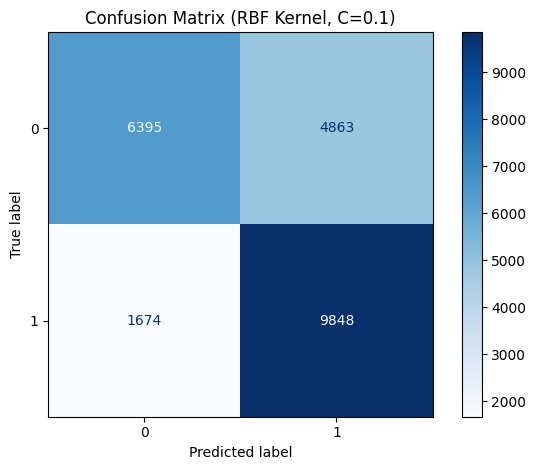

ROC AUC Score: 0.7728


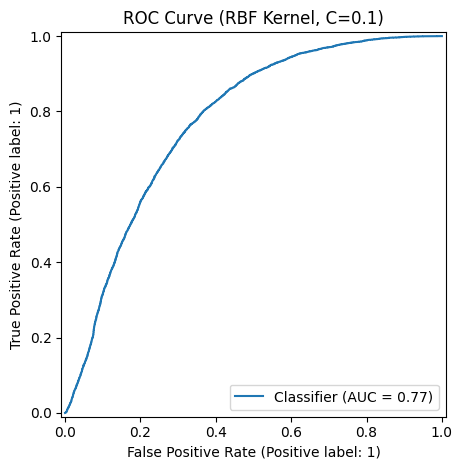


Training SVC with kernel='rbf', C=1
Training Accuracy: 0.7707
Testing Accuracy: 0.7616
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.60      0.71     11258
           1       0.70      0.92      0.80     11522

    accuracy                           0.76     22780
   macro avg       0.79      0.76      0.75     22780
weighted avg       0.79      0.76      0.76     22780



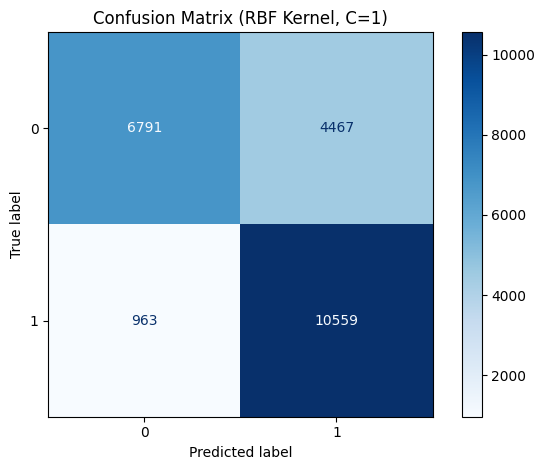

ROC AUC Score: 0.8252


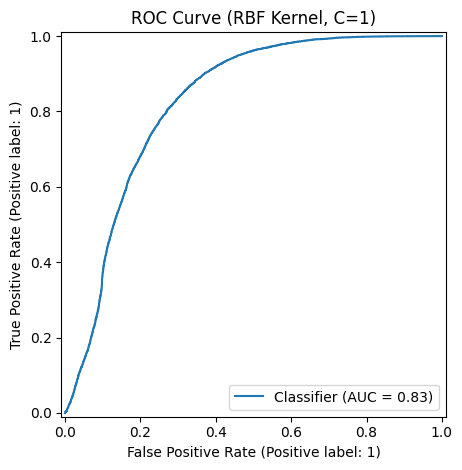


Training SVC with kernel='rbf', C=10
Training Accuracy: 0.8165
Testing Accuracy: 0.7955
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.65      0.76     11258
           1       0.73      0.93      0.82     11522

    accuracy                           0.80     22780
   macro avg       0.82      0.79      0.79     22780
weighted avg       0.82      0.80      0.79     22780



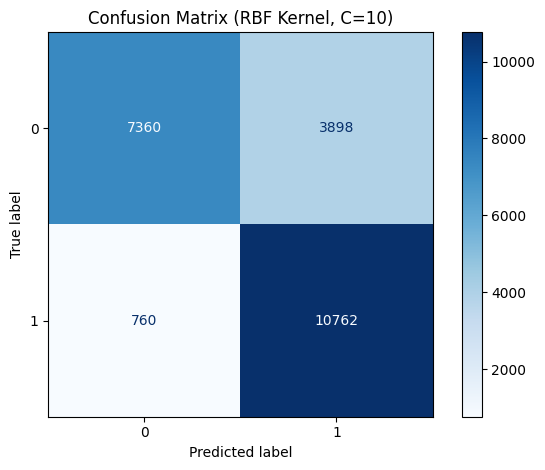

ROC AUC Score: 0.8593


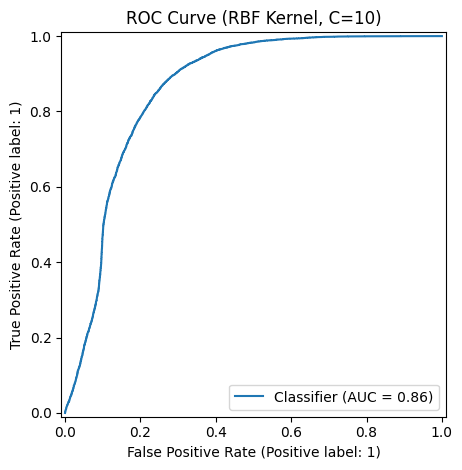


Training SVC with kernel='rbf', C=100
Training Accuracy: 0.8639
Testing Accuracy: 0.8245
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80     11258
           1       0.77      0.93      0.84     11522

    accuracy                           0.82     22780
   macro avg       0.84      0.82      0.82     22780
weighted avg       0.84      0.82      0.82     22780



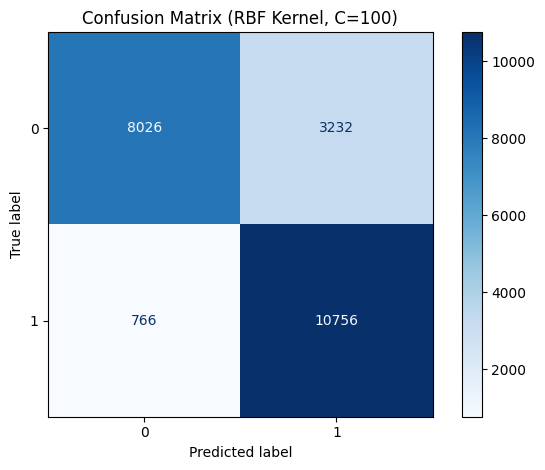

ROC AUC Score: 0.8788


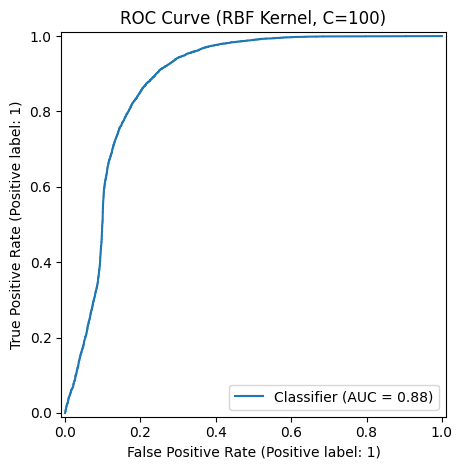

In [16]:
# Define different C values
C_values = [0.01, 0.1, 1, 10, 100]

# Try RBF kernel on full data
for C in C_values:
    print(f"\nTraining SVC with kernel='rbf', C={C}")

    model = SVC(kernel='rbf', C=C, random_state=42)
    model.fit(X_train_transformed, y_train)

    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)

    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Blues')
    plt.title(f"Confusion Matrix (RBF Kernel, C={C})")
    plt.tight_layout()
    plt.show()

    y_scores = model.decision_function(X_test_transformed)
    auc = roc_auc_score(y_test, y_scores)
    print(f"ROC AUC Score: {auc:.4f}")
    RocCurveDisplay.from_predictions(y_test, y_scores)
    plt.title(f"ROC Curve (RBF Kernel, C={C})")
    plt.tight_layout()
    plt.show()


In [17]:
from sklearn.decomposition import PCA

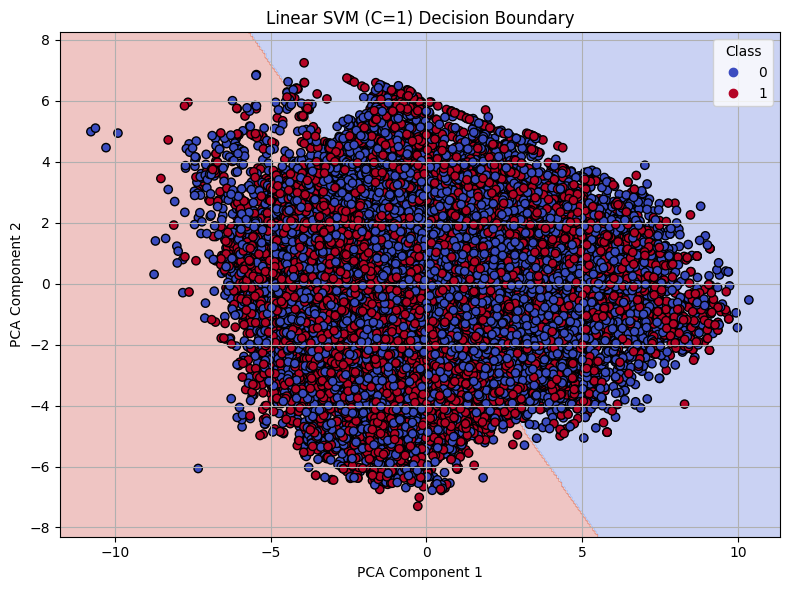

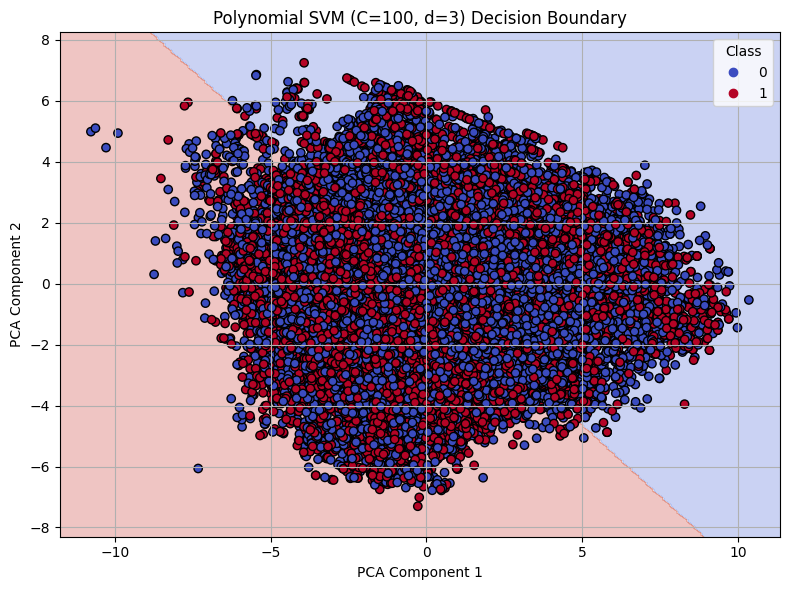

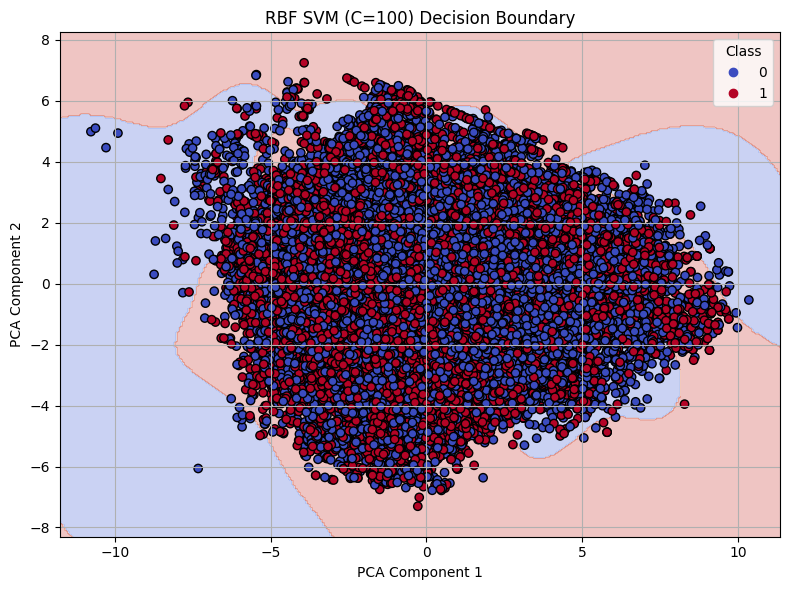

In [18]:
# Reduce features to 2D using PCA
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_train_transformed)
X_test_2D = pca.transform(X_test_transformed)

# Common plot function
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(*scatter.legend_elements(), title="Class")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Linear Kernel
linear_model = LinearSVC(C=1, max_iter=10000, random_state=42)
linear_model.fit(X_2D, y_train)
plot_decision_boundary(linear_model, X_2D, y_train, "Linear SVM (C=1) Decision Boundary")

# Polynomial Kernel
poly_model = SVC(kernel='poly', C=100, degree=3, random_state=42)
poly_model.fit(X_2D, y_train)
plot_decision_boundary(poly_model, X_2D, y_train, "Polynomial SVM (C=100, d=3) Decision Boundary")

# RBF Kernel
rbf_model = SVC(kernel='rbf', C=100, random_state=42)
rbf_model.fit(X_2D, y_train)
plot_decision_boundary(rbf_model, X_2D, y_train, "RBF SVM (C=100) Decision Boundary")
